# Comparación automática con PyCaret

En `comparacion_modelos.ipynb` se compararon a mano tres algoritmos y se eligió el Random Forest. PyCaret permite hacer la misma pregunta a mayor escala: entrenar y validar 15 algoritmos con pocas líneas de código.

El objetivo es usar PyCaret como **referencia externa**: ¿hay algún algoritmo que rinda claramente mejor que el modelo elegido?

> **Entorno.** PyCaret 3.3.2 necesita Python 3.9–3.11 y versiones de pandas y scikit-learn anteriores a las del resto del proyecto. Por eso este notebook se ejecuta en un entorno aparte (ver `requirements-pycaret.txt` y el README). Solo depende de `data/telco_churn.csv`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycaret
from sklearn.model_selection import train_test_split
from pycaret.classification import setup, compare_models, predict_model, pull

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
print("PyCaret", pycaret.__version__)

PyCaret 3.3.2


## 1. Datos

A PyCaret se le entregan los datos casi crudos: solo se convierte `TotalCharges` a número y se codifica el objetivo. No se aplica la selección de variables hecha a mano (`cantidad_servicios`, columnas eliminadas), así que la comparación también sirve para comprobar si esa selección hizo perder información.

Se usa la misma partición entrenamiento/prueba que en el resto del proyecto.

In [2]:
df = pd.read_csv("../data/telco_churn.csv")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Churn"])
print(train.shape, test.shape)

(5634, 21) (1409, 21)


## 2. Experimento 1: configuración por defecto

`setup` detecta los tipos de columna y arma el preprocesamiento (imputación, codificación de categóricas). `customerID` se excluye porque es un identificador.

In [3]:
exp1 = setup(
    data=train, test_data=test, target="Churn",
    ignore_features=["customerID"],
    fold=5, session_id=42, index=False,
    verbose=False, system_log=False,
)
pull()

,Description,Value
0,Session id,42
1,Target,Churn
2,Target type,Binary
3,Original data shape,"(7043, 21)"
4,Transformed data shape,"(7043, 41)"
5,Transformed train set shape,"(5634, 41)"
6,Transformed test set shape,"(1409, 41)"
7,Ignore features,1
8,Numeric features,4
9,Categorical features,15


`compare_models` entrena todos los algoritmos disponibles con validación cruzada de 5 particiones. Se ordena por AUC porque no depende del umbral de decisión.

In [4]:
mejor_auc = compare_models(sort="AUC", verbose=False)
resultados_auc = pull()
resultados_auc

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8019,0.8468,0.5278,0.6584,0.5856,0.4576,0.4626,0.640
lr,Logistic Regression,0.8042,0.8457,0.5498,0.6570,0.5985,0.4704,0.4738,0.764
ada,Ada Boost Classifier,0.8042,0.8443,0.5358,0.6627,0.5921,0.4652,0.4701,0.314
catboost,CatBoost Classifier,0.7961,0.8405,0.5137,0.6459,0.5718,0.4403,0.4456,1.990
ridge,Ridge Classifier,0.8012,0.8384,0.5157,0.6614,0.5793,0.4518,0.4579,0.150
lda,Linear Discriminant Analysis,0.8008,0.8384,0.5592,0.6442,0.5984,0.4669,0.4692,0.144
lightgbm,Light Gradient Boosting Machine,0.7929,0.8342,0.5164,0.6349,0.5690,0.4347,0.4390,1.848
xgboost,Extreme Gradient Boosting,0.7804,0.8220,0.5104,0.6017,0.5521,0.4080,0.4105,0.244
nb,Naive Bayes,0.6929,0.8218,0.8495,0.4583,0.5952,0.3820,0.4293,0.162
rf,Random Forest Classifier,0.7849,0.8201,0.4870,0.6205,0.5455,0.4073,0.4126,0.482


Para ubicar los resultados, el gráfico añade los tres modelos entrenados a mano en `comparacion_modelos.ipynb` (AUC de validación cruzada sobre el mismo conjunto de entrenamiento).

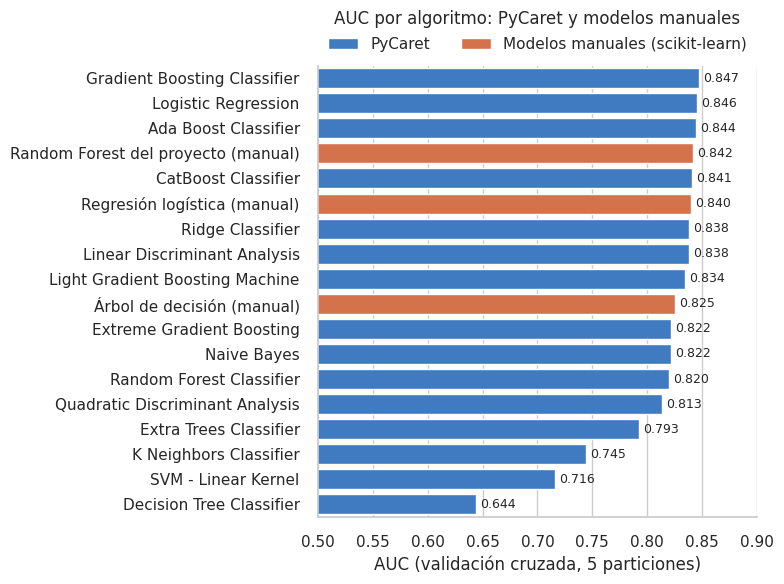

In [5]:
# AUC de validación cruzada de los modelos manuales (tabla de la sección 4 de comparacion_modelos.ipynb)
manuales = pd.DataFrame({
    "Model": ["Random Forest del proyecto (manual)", "Regresión logística (manual)", "Árbol de decisión (manual)"],
    "AUC": [0.842, 0.840, 0.825],
    "Origen": "Modelos manuales (scikit-learn)",
})

pycaret_auc = resultados_auc.loc[resultados_auc["Model"] != "Dummy Classifier", ["Model", "AUC"]].assign(Origen="PyCaret")
datos = pd.concat([pycaret_auc, manuales]).sort_values("AUC", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=datos, x="AUC", y="Model", hue="Origen", dodge=False,
            palette={"PyCaret": "#2a78d6", "Modelos manuales (scikit-learn)": "#eb6834"}, ax=ax)
for barras in ax.containers:
    ax.bar_label(barras, fmt="%.3f", padding=3, fontsize=9)
ax.set(xlim=(0.5, 0.9), xlabel="AUC (validación cruzada, 5 particiones)", ylabel="")
ax.set_title("AUC por algoritmo: PyCaret y modelos manuales", pad=30)
ax.legend(title="", loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("../img/pycaret_auc.png", dpi=150, facecolor="white")
plt.show()

Mejor modelo del experimento, evaluado en el conjunto de prueba:

In [6]:
print(type(mejor_auc).__name__)
predict_model(mejor_auc, verbose=False)
pull()

GradientBoostingClassifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.8027,0.8434,0.516,0.6655,0.5813,0.455,0.4613


## 3. Experimento 2: con balanceo de clases

Por defecto PyCaret no corrige el desbalance, y por eso el recall del experimento 1 ronda 0,5: los modelos detectan solo la mitad de las cancelaciones. Los modelos manuales usan `class_weight="balanced"`.

Para que la comparación en F1 y recall sea justa, se repite el experimento con `fix_imbalance=True` (sobremuestreo con SMOTE dentro de cada partición) y se ordena por F1.

In [7]:
exp2 = setup(
    data=train, test_data=test, target="Churn",
    ignore_features=["customerID"],
    fold=5, session_id=42, index=False,
    fix_imbalance=True,
    verbose=False, system_log=False,
)

mejor_f1 = compare_models(sort="F1", verbose=False)
resultados_f1 = pull()
resultados_f1

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7517,0.8450,0.8033,0.5213,0.6322,0.4575,0.4818,0.512
ada,Ada Boost Classifier,0.7941,0.8448,0.6482,0.6057,0.6257,0.4840,0.4849,0.450
ridge,Ridge Classifier,0.7442,0.8426,0.8007,0.5124,0.6247,0.4448,0.4703,0.186
lda,Linear Discriminant Analysis,0.7440,0.8427,0.8007,0.5122,0.6245,0.4445,0.4701,0.178
gbc,Gradient Boosting Classifier,0.7984,0.8465,0.5967,0.6271,0.6113,0.4753,0.4757,1.244
nb,Naive Bayes,0.7000,0.8200,0.8421,0.4648,0.5988,0.3900,0.4340,0.172
qda,Quadratic Discriminant Analysis,0.6844,0.8268,0.8468,0.4527,0.5884,0.3703,0.4199,0.162
catboost,CatBoost Classifier,0.7929,0.8376,0.5525,0.6245,0.5861,0.4487,0.4503,5.486
lightgbm,Light Gradient Boosting Machine,0.7925,0.8352,0.5418,0.6263,0.5808,0.4439,0.4461,10.844
xgboost,Extreme Gradient Boosting,0.7831,0.8221,0.5224,0.6067,0.5612,0.4182,0.4204,0.564


In [8]:
print(type(mejor_f1).__name__)
predict_model(mejor_f1, verbose=False)
pull()

LogisticRegression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.736,0.8395,0.7861,0.5017,0.6125,0.4267,0.4515


## 4. Conclusiones

- **Ningún algoritmo supera con claridad al modelo elegido.** PyCaret comparó 15 algoritmos más un clasificador de referencia (*dummy*). Los mejores quedan en un AUC de 0,84–0,85 (Gradient Boosting 0,847, regresión logística 0,846, AdaBoost 0,844). El Random Forest del proyecto está en ese mismo nivel (0,842): la diferencia con el primero es de 5 milésimas, menor que la variación entre particiones.
- **Ajustar los hiperparámetros importa.** El Random Forest que PyCaret entrena con valores por defecto obtiene un AUC de 0,820, y el del proyecto, ajustado, 0,842. En el árbol de decisión la diferencia es mayor: 0,644 sin ajustar frente a 0,825 con la profundidad limitada.
- **La selección manual de variables no perdió información.** PyCaret usó las 19 variables originales (40 columnas tras codificar) y llega al mismo techo que los modelos manuales con 17 columnas.
- **El desbalance hay que tratarlo.** Sin corregirlo, los modelos detectan solo la mitad de las cancelaciones (recall ≈ 0,5). Con `fix_imbalance=True`, el mejor modelo por F1 es la regresión logística, que en prueba llega a F1 0,613 y recall 0,786; el Random Forest del proyecto obtiene F1 0,631 y recall 0,762.

En resumen: con estas variables el rendimiento tiene un techo cercano a 0,85 de AUC, sea cual sea el algoritmo, y el modelo del proyecto ya está en él. Para mejorar haría falta información nueva sobre los clientes (reclamos, uso del servicio, cambios de plan), no un modelo más complejo.